https://www.kaggle.com/datasets/notshrirang/spotify-million-song-dataset

https://colab.research.google.com/drive/1HLwhqRmgGEVdDGIq6YhMVhxIOOr_uVVM#scrollTo=_Nv9AbO69cgu

Dataset Spotify Million Song Dataset trên Kaggle là một tập dữ liệu phổ biến bao gồm thông tin chi tiết về các bài hát, nghệ sĩ, đường dẫn liên kết và đặc biệt là lời bài hát (lyrics) của rất nhiều ca khúc khác nhau.

1. Cấu trúc các cột dữ liệu (Columns)
Mặc dù có tên là "Million Song Dataset", tập dữ liệu này (spotify_millsongdata.csv) thường chứa các trường thông tin cơ bản sau cho mỗi bản ghi:

artist: Tên của nghệ sĩ hoặc ban nhạc trình bày bài hát.

song: Tên của bài hát.

link: Đường dẫn hoặc URL liên kết đến bài hát (thường liên kết với nguồn gốc dữ liệu lời bài hát).

text (hoặc lyrics): Toàn bộ phần lời của bài hát dưới dạng văn bản (text).

2. Các ứng dụng phổ biến (Use Cases)
Dataset này chủ yếu được sử dụng cho các dự án liên quan đến Xử lý Ngôn ngữ Tự nhiên (NLP), học máy và phân tích dữ liệu âm nhạc:

Hệ thống gợi ý bài hát (Song Recommender Systems):

Dựa vào nội dung lời bài hát hoặc tên nghệ sĩ để xây dựng hệ thống gợi ý bài hát tương tự (Content-based Filtering).

Sử dụng các kỹ thuật trích xuất đặc trưng văn bản như TF-IDF kết hợp với Cosine Similarity để tìm các bài hát có phong cách lời bài hát giống nhau.

Phân loại và gom cụm âm nhạc (Classification & Clustering):

Gom nhóm các bài hát có chủ đề, cảm xúc hoặc từ vựng tương tự nhau bằng các thuật toán học không giám sát (K-Means, Hierarchical Clustering).

Phân tích cảm xúc bài hát (Sentiment Analysis):

Đánh giá sắc thái cảm xúc (vui, buồn, tích cực, tiêu cực) của lời bài hát.

Tạo sinh văn bản / Lời bài hát tự động (Text Generation / LLM Fine-Tuning):

Dùng làm dữ liệu huấn luyện hoặc tinh chỉnh (fine-tune) cho các mô hình ngôn ngữ để sáng tác thơ hoặc viết lời bài hát theo phong cách của một nghệ sĩ cụ thể.

In [17]:
#import the dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize


from wordcloud import wordcloud: Thư viện tạo biểu đồ đám mây từ (Word Cloud) để trực quan hóa những từ xuất hiện nhiều nhất trong lời bài hát của nghệ sĩ hoặc thể loại nào đó.

3. Xử lý ngôn ngữ tự nhiên (NLP) và Học máy
from sklearn.feature_extraction.text import TfidfVectorizer: Chuyển đổi văn bản (lời bài hát) thành dạng số (vector TF-IDF - Term Frequency-Inverse Document Frequency), đo lường mức độ quan trọng của một từ trong bài hát so với toàn bộ tập dữ liệu.

from sklearn.metrics.pairwise import cosine_similarity: Tính toán độ tương đồng cosine giữa các vector bài hát. Giá trị càng gần 1 nghĩa là lời của hai bài hát càng giống nhau về mặt từ vựng.

import re: Thư viện xử lý biểu thức chính quy (Regular Expression), dùng để làm sạch văn bản (loại bỏ ký tự đặc biệt, dấu câu, khoảng trắng thừa trong lời bài hát).

import nltk: Thư viện hàng đầu cho xử lý ngôn ngữ tự nhiên (Natural Language Toolkit).

from nltk.corpus import stopwords: Dùng để lọc bỏ các "từ dừng" (stop words) không mang nhiều ý nghĩa ngữ nghĩa trong tiếng Anh (như the, is, at, which, and...) để tập trung vào từ khóa chính của bài hát.

from nltk.tokenize import word_tokenize: Dùng để tách một câu hoặc đoạn lời bài hát thành danh sách các từ đơn lẻ (tokens).

In [1]:
import kagglehub
path = kagglehub.dataset_download("notshrirang/spotify-million-song-dataset")

100%|██████████| 20.7M/20.7M [00:00<00:00, 29.2MB/s]

Extracting files...


In [4]:
import os
# Liệt kê các file trong thư mục tải về để tìm file CSV
files = os.listdir(path)
print("📄 Danh sách file:", files)

# Đọc file CSV (Telco Churn thường có tên dạng WA_Fn-UseC_-Telco-Customer-Churn.csv)
csv_file = [f for f in files if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, csv_file))

# Hiển thị 5 dòng dữ liệu đầu tiên
display(df.head())

📄 Danh sách file: ['spotify_millsongdata.csv']


,artist,song,link,text
0,ABBA,Ahe's My Kind Of Girl,/a/abba/ahes+my+kind+of+girl_20598417.html,"Look at her face, it's a wonderful face \r\nA..."
1,ABBA,"Andante, Andante",/a/abba/andante+andante_20002708.html,"Take it easy with me, please \r\nTouch me gen..."
2,ABBA,As Good As New,/a/abba/as+good+as+new_20003033.html,I'll never know why I had to go \r\nWhy I had...
3,ABBA,Bang,/a/abba/bang_20598415.html,Making somebody happy is a question of give an...
4,ABBA,Bang-A-Boomerang,/a/abba/bang+a+boomerang_20002668.html,Making somebody happy is a question of give an...


In [5]:
df.shape

(57650, 4)

In [7]:
df.head()

,artist,song,link,text
0,ABBA,Ahe's My Kind Of Girl,/a/abba/ahes+my+kind+of+girl_20598417.html,"Look at her face, it's a wonderful face \r\nA..."
1,ABBA,"Andante, Andante",/a/abba/andante+andante_20002708.html,"Take it easy with me, please \r\nTouch me gen..."
2,ABBA,As Good As New,/a/abba/as+good+as+new_20003033.html,I'll never know why I had to go \r\nWhy I had...
3,ABBA,Bang,/a/abba/bang_20598415.html,Making somebody happy is a question of give an...
4,ABBA,Bang-A-Boomerang,/a/abba/bang+a+boomerang_20002668.html,Making somebody happy is a question of give an...


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57650 entries, 0 to 57649
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   artist  57650 non-null  object
 1   song    57650 non-null  object
 2   link    57650 non-null  object
 3   text    57650 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB


In [9]:
df.isnull().sum()

,0
artist,0
song,0
link,0
text,0


In [12]:
#top artist and songs
top_artits = df['artist'].value_counts().head(10)
print("\nTop 10 Artist")
print(top_artits)

top_songs = df['song'].value_counts().head(10)
print("\nTop 10 Songs")
print(top_songs)


Top 10 Artist
artist
Donna Summer        191
Gordon Lightfoot    189
Bob Dylan           188
George Strait       188
Loretta Lynn        187
Alabama             187
Cher                187
Reba Mcentire       187
Chaka Khan          186
Dean Martin         186
Name: count, dtype: int64

Top 10 Songs
song
Have Yourself A Merry Little Christmas    35
Angel                                     28
Home                                      27
Hold On                                   27
I Believe                                 26
Crazy                                     25
Silent Night                              25
The Christmas Song                        25
Forever                                   25
I Love You                                22
Name: count, dtype: int64


In [13]:
df = df.sample(10000)

df = df.drop('link', axis=1).reset_index(drop=True)
df.head(10)

,artist,song,text
0,Pet Shop Boys,How I Learned To Hate Rock 'n' Roll,Someone states the obvious \r\nSomeone sneers...
1,Beautiful South,Losing Things,I'm losing things \r\nThat's what old-fashion...
2,Nina Simone,Buck,You're a whole lot a man \r\nJust take a look...
3,Tom T. Hall,Promise And The Dream,"There's a sadness in your singing, I have neve..."
4,Judds,Let Me Tell You About Love,Well ever since the day that time began \r\nT...
5,Utada Hikaru,Taking My Money Back,"Boy you make it hard, you make it hard to leav..."
6,Vengaboys,Boom Boom Boom,Ohohoh ohohoh \r\nOhohoh ohohoh \r\nVengaboy...
7,Reba Mcentire,Faith In Love,We felt this coming on \r\nWe've seen it for ...
8,Queensryche,Saved,"I opened my eyes, \r\nBarely alive, without y..."
9,Emmylou Harris,A Ways To Go,(Lainie Marsh) \r\nI hear the clock a tickin'...


In [14]:
df.shape

(10000, 3)

1. df = df.sample(10000)
Ý nghĩa: Lấy ngẫu nhiên 10.000 dòng (bài hát) từ toàn bộ tập dữ liệu gốc (df).

Lý do thực hiện: Tập dữ liệu gốc chứa rất nhiều bài hát. Việc tính toán ma trận độ tương đồng (như cosine_similarity) cho hàng triệu bài hát sẽ tiêu tốn rất nhiều bộ nhớ RAM và thời gian xử lý (dễ dẫn đến lỗi tràn bộ nhớ MemoryError khi huấn luyện cục bộ). Lấy mẫu 10.000 bài là bước tối ưu phổ biến để thử nghiệm, chạy code nhanh chóng và xây dựng bản mẫu (prototype).

2. df = df.drop('link', axis=1).reset_index(drop=True)
Dòng này thực hiện hai thao tác gộp liên tiếp:

drop('link', axis=1): Xóa cột có tên là 'link' (axis=1 nghĩa là xóa theo cột). Cột này chứa đường dẫn URL của bài hát, vốn không mang lại giá trị gì cho việc phân tích văn bản hay gợi ý bài hát dựa trên lời (lyrics).

.reset_index(drop=True): Sau khi lấy ngẫu nhiên 10.000 dòng ở bước trên, các chỉ số dòng (index) cũ sẽ bị xáo trộn (ví dụ: dòng 5, dòng 1205, dòng 45...). Lệnh này giúp đặt lại chỉ số (index) từ 0 đến 9999 theo thứ tự tuần tự sạch sẽ. Tham số drop=True đảm bảo rằng index cũ không bị lưu thành một cột thừa trong DataFrame.

In [16]:
pip install wordcloud

In [18]:
#wordcloud for song lycris
all_lycris = " ".join(df['text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(all_lycris)

để tạo và vẽ biểu đồ đám mây từ (Word Cloud) nhằm trực quan hóa những từ ngữ xuất hiện nhiều nhất trong toàn bộ phần lời của 10.000 bài hát đã được lấy mẫu.

1. all_lycris = " ".join(df['text'].dropna())
df['text'].dropna(): Lấy toàn bộ cột chứa lời bài hát (text) và loại bỏ các dòng bị thiếu giá trị (NaN hoặc None) để tránh lỗi khi xử lý chuỗi.

" ".join(...): Nối tất cả các đoạn lời bài hát (vốn là các chuỗi văn bản riêng lẻ của từng bài) thành một chuỗi văn bản khổng lồ duy nhất, cách nhau bằng khoảng trắng.

Ý nghĩa: Biến toàn bộ kho lời bài hát thành một "cuốn sách" dài chứa tất cả các từ trong 10.000 bài hát để thư viện WordCloud có thể quét và thống kê tần suất xuất hiện của từng từ.

2. wordcloud = WordCloud(width=800, height=400, background_color="white").generate(all_lycris)
WordCloud(...): Khởi tạo đối tượng tạo đám mây từ với các cấu hình:

width=800, height=400: Kích thước khung hình chữ nhật của ảnh (chiều rộng 800 pixel, chiều cao 400 pixel).

background_color="white": Đặt màu nền của ảnh là màu trắng cho dễ nhìn.

.generate(all_lycris): Truyền chuỗi văn bản khổng lồ vừa nối vào để thuật toán tự động đếm tần suất xuất hiện của các từ. Từ nào xuất hiện càng nhiều lần thì kích thước hiển thị trên ảnh sẽ càng lớn.

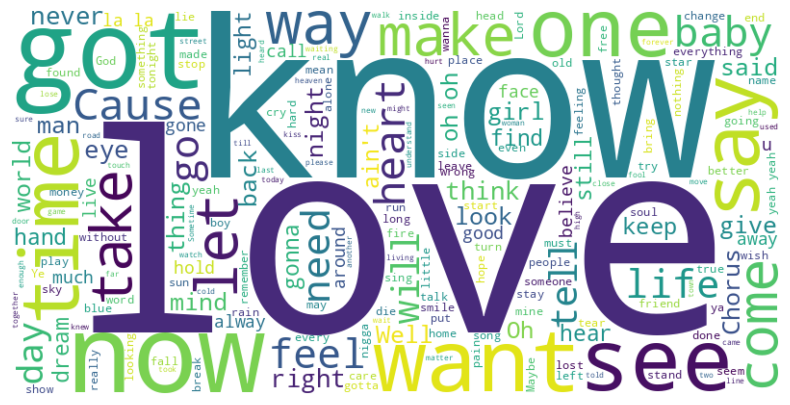

In [19]:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Tắt các trục tọa độ x, y
plt.show()

In [20]:
#data preprocessing

#download nltk data
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [21]:
stop_words = set(stopwords.words('english'))

1. Tải các tài nguyên cần thiết từ NLTK
nltk.download("punkt"): Tải mô hình tách từ/tách câu (Punkt tokenizer). Mô hình này giúp thư viện NLTK hiểu được cách cắt một câu dài hoặc một đoạn văn bản thành các từ đơn lẻ (tokens) một cách thông minh (ví dụ: phân biệt dấu chấm kết thúc câu với dấu chấm viết tắt).

nltk.download("punkt_tab"): Tải bảng dữ liệu phụ trợ cho mô hình Punkt (đây là bản cập nhật tài nguyên cần thiết cho các phiên bản NLTK mới để tránh lỗi thiếu file token).

nltk.download("stopwords"): Tải bộ từ dừng (stopwords) cho nhiều ngôn ngữ khác nhau.


2. stop_words = set(stopwords.words('english'))
stopwords.words('english'): Lấy danh sách các "từ dừng" (stop words) trong tiếng Anh. Đây là những từ xuất hiện cực kỳ nhiều nhưng mang rất ít ý nghĩa ngữ nghĩa để phân biệt bài hát này với bài hát khác (ví dụ như: the, is, at, which, and, on, you, I...).

set(...): Chuyển danh sách đó thành kiểu dữ liệu set (tập hợp) trong Python.

Lý do dùng set: Khi bạn cần kiểm tra xem một từ có nằm trong danh sách từ dừng hay không (lọc từ), tìm kiếm trên set có tốc độ cực kỳ nhanh (O(1)) so với việc tìm trên danh sách thông thường (list), giúp tăng tốc độ xử lý cho hàng nghìn bài hát.


In [24]:
def preprocess_text(text):
  #remove specila characters and numbers
  text = re.sub(r"[^a-zA-Z\s]", "", text)
  #Convert to lowercase
  text =text.lower()
  #tokenize and remove stopwords
  tokens = word_tokenize(text)
  tokens = [word for word in tokens if word not in stop_words]
  return " ".join(tokens)

hàm tiền xử lý văn bản (preprocess_text). Hàm này đóng vai trò là "bộ lọc" để biến một đoạn lời bài hát thô (có chứa dấu câu, chữ hoa/thường lẫn lộn, từ rác) thành một chuỗi các từ khóa sạch sẽ, chuẩn mực trước khi đưa vào mô hình học máy.

re.sub(...): Sử dụng biểu thức chính quy (Regular Expression) để tìm và thay thế.

r"[^a-zA-Z\s]": Biểu thức này đại diện cho bất kỳ ký tự nào không phải là chữ cái tiếng Anh từ a-z, A-Z và khoảng trắng (\s).

Ý nghĩa: Loại bỏ toàn bộ các dấu câu (dấu phẩy, dấu chấm, dấu chấm hỏi, dấu nháy đơn...), các con số (0-9) và ký tự đặc biệt. Lời bài hát sau bước này chỉ còn lại các chữ cái và khoảng trắng.

word_tokenize(text): Cắt chuỗi văn bản thành một danh sách các từ đơn lẻ (ví dụ: ["i", "love", "you"]).

List Comprehension ([word for word in tokens if word not in stop_words]): Duyệt qua từng từ trong danh sách, nếu từ đó không nằm trong danh sách từ dừng (stop_words như the, is, at...) thì giữ lại, còn lại sẽ bị loại bỏ. Bước này giúp loại bỏ các từ vô nghĩa, giữ lại các từ khóa có trọng số cao về mặt nội dung của bài hát.

In [25]:
#apply preprocessing to lycris
df["cleaned_text"] = df['text'].apply(preprocess_text)

In [26]:
#vectorization with TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned_text'])

chuyển đổi văn bản (lời bài hát đã làm sạch) thành các vector số học bằng kỹ thuật TF-IDF (Term Frequency-Inverse Document Frequency), giúp máy tính có thể "hiểu" và đo lường sự khác biệt về từ vựng giữa các bài hát.

TfidfVectorizer: Thuật toán tính toán trọng số của từng từ dựa trên mức độ xuất hiện của nó trong một bài hát so với toàn bộ 10.000 bài hát. Từ nào xuất hiện nhiều trong bài này nhưng ít xuất hiện ở các bài khác sẽ có trọng số TF-IDF rất cao (từ khóa đặc trưng).

max_features=5000: Giới hạn chỉ giữ lại 5.000 từ quan trọng và xuất hiện nhiều nhất trong toàn bộ tập dữ liệu để làm đặc trưng.

Lý do: Giúp giảm kích thước ma trận, tiết kiệm bộ nhớ RAM và loại bỏ các từ quá hiếm gặp (vốn không mang nhiều ý nghĩa chung cho việc gợi ý).

.fit_transform(...): Gồm 2 bước gộp lại:

fit: Quét toàn bộ cột cleaned_text để học từ điển (xác định 5.000 từ vựng quan trọng nhất theo max_features).

transform: Chuyển đổi từng bài hát thành một dòng trong ma trận số học.

In [28]:
#Compute Cosine Similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

tính toán ma trận độ tương đồng (Cosine Similarity) giữa tất cả các bài hát với nhau dựa trên các vector TF-IDF đã tạo ở bước trước.

cosine_similarity(...): Hàm tính khoảng cách góc (Cosine) giữa các vector. Góc này cho biết mức độ trùng lặp về từ vựng giữa hai bài hát:Nếu góc bằng 0 $\rightarrow$ Cosine bằng 1 (hai bài hát giống hệt nhau về từ vựng/lời bài hát).Nếu góc vuông $\rightarrow$ Cosine bằng 0 (hai bài hát hoàn toàn không liên quan, không chung từ nào).

In [29]:
df.head()

,artist,song,text,cleaned_text
0,Pet Shop Boys,How I Learned To Hate Rock 'n' Roll,Someone states the obvious \r\nSomeone sneers...,someone states obvious someone sneers love som...
1,Beautiful South,Losing Things,I'm losing things \r\nThat's what old-fashion...,im losing things thats oldfashioned love bring...
2,Nina Simone,Buck,You're a whole lot a man \r\nJust take a look...,youre whole lot man take look great big hands ...
3,Tom T. Hall,Promise And The Dream,"There's a sadness in your singing, I have neve...",theres sadness singing never heard theres dyin...
4,Judds,Let Me Tell You About Love,Well ever since the day that time began \r\nT...,well ever since day time began theres thing tw...


In [30]:
cosine_sim

array([[1.        , 0.01162483, 0.00131711, ..., 0.        , 0.0482636 ,
        0.00226042],
       [0.01162483, 1.        , 0.08080557, ..., 0.05920705, 0.04142548,
        0.01998854],
       [0.00131711, 0.08080557, 1.        , ..., 0.02218221, 0.05201198,
        0.01571513],
       ...,
       [0.        , 0.05920705, 0.02218221, ..., 1.        , 0.00615561,
        0.02789134],
       [0.0482636 , 0.04142548, 0.05201198, ..., 0.00615561, 1.        ,
        0.02461354],
       [0.00226042, 0.01998854, 0.01571513, ..., 0.02789134, 0.02461354,
        1.        ]])

In [31]:
#Recommendation function
def recommed_songs(song_name, cosine_sim=cosine_sim, df=df, top_n=5):
  #Find the index of the song
  idx = df[df['song'].str.lower() == song_name.lower()].index
  if(len(idx) == 0):
    return "Song not found in the dataset!"
  idx = idx[0]

  #Get similarity scores
  sim_scores = list(enumerate(cosine_sim[idx]))
  sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
  sim_scores = sim_scores[1:top_n+1]

  #Get song indices
  song_indices = [i[0] for i in sim_scores]

  #Return top n similar songs
  return df[['artist', 'song']].iloc[song_indices]


dùng để tìm và trả về danh sách các bài hát có lời tương tự nhất với một bài hát do người dùng nhập vào.

df['song'].str.lower() == song_name.lower(): Chuyển tên bài hát trong DataFrame và tên bài hát người dùng nhập về chữ thường hết để so sánh, tránh lỗi do viết hoa/thường khác nhau. Lệnh này tìm xem bài hát có tồn tại trong dữ liệu hay không.

if len(idx) == 0: Nếu không tìm thấy bài hát nào khớp, hàm trả về thông báo lỗi "Song not found in the dataset!".

idx = idx[0]: Nếu tìm thấy, lấy ra chỉ số (index) dòng đầu tiên của bài hát đó trong DataFrame (ví dụ: bài hát nằm ở hàng thứ 45).

enumerate(cosine_sim[idx]): Lấy ra hàng thứ idx trong ma trận cosine_sim (chứa độ tương đồng của bài hát này với tất cả các bài hát còn lại) và gắn kèm index gốc của từng bài. Kết quả có dạng: [(0, 0.05), (1, 0.82), (2, 0.12), ...].

sorted(..., reverse=True): Sắp xếp danh sách điểm tương đồng theo thứ tự giảm dần (từ bài giống nhất đến bài ít giống nhất).

sim_scores = sim_scores[1:top_n+1]:

Cắt danh sách để lấy ra số lượng bài gợi ý mong muốn (top_n, mặc định là 5).

Bắt đầu từ vị trí 1 (bỏ qua vị trí 0 vì đó chính là bài hát gốc mà người dùng vừa nhập, độ tương đồng với chính nó luôn bằng 1.0).

song_indices = [i[0] for i in sim_scores]: Lấy ra danh sách các chỉ số (index) của top các bài hát phù hợp nhất.

df[['artist', 'song']].iloc[song_indices]: Dùng lệnh .iloc để lọc ra tên nghệ sĩ (artist) và tên bài hát (song) tương ứng với các index đó, sau đó trả về một bảng DataFrame hoàn chỉnh chứa các bài hát được gợi ý cho người dùng.



In [32]:
df['song'][2]

'Buck'

In [35]:
#Example Recommendation
print("\nRecommendation for the song 'Blinded By Rainbows'")
recommendations = recommed_songs("Christmas Memories")
print(recommendations)


Recommendation for the song 'Blinded By Rainbows'
                  artist                               song
2859        Cyndi Lauper                   Mary's Boy Child
2999       Michael Buble  Christmas (Baby Please Come Home)
9185        Cyndi Lauper                        Three Ships
7494  Harry Connick, Jr.                     This Christmas
6672         Pat Benatar     Please Come Home For Christmas
